# Investigate Unassigned & Artifact_Spillover (UMAP + Leiden)

Companion to `investigate_unassigned_spillover.ipynb`: same question, unsupervised clustering approach.

**Goal:** investigate **Unassigned** and **Artifact_Spillover** cells using single-cell-style embedding (PCA → neighbors → UMAP → Leiden), not by picking per-channel intensity cutoffs.

Binary thresholds are partly subjective, so large Unassigned / spillover pools can reflect cutoff choice, incomplete rules, or real mixed/artifact phenotypes. Clustering in continuous marker space asks: do these cells form coherent neighborhoods, sit between known types, or look like noise?

Related notebooks:
- `investigate_unassigned_spillover.ipynb` — profiles which channels drive those labels
- `determine_binary_threshold.ipynb` / `analyze_cell_types_from_markers.ipynb` — thresholding and rule-based typing (different goal)

## Input

- `../output/celldive_protein_matrix_celltypes.h5ad` — cell × marker matrix (~900k cells × 23 channels) with `cell_type`, QC flags, spatial coords.

## Pipeline

1. **Library-size QC** — histogram of total intensity per cell.
2. **Arcsinh + scale** — transform and z-score markers.
3. **PCA → neighbors** — PC space and kNN graph.
4. **UMAP** — 2D embedding (slow on full data; keep in its own cell).
5. **Leiden** — graph clustering.
6. **Plot (default palette)** — Scanpy's default categorical colors for `cell_type` and Leiden.
7. **Plot (improved palette)** — high-contrast colors + Unassigned/spillover highlight.
8. **Interpret** — what the embedding implies for Unassigned / Artifact_Spillover.
9. **Drill / salvage** — multi-resolution Leiden crosstabs and marker profiles for Unassigned / spillover.
10. **Binary gates** — spillover pair breakdown, binary positivity, phenotyping matrix fit per enriched cluster.

## Notes

- This is **not** threshold / cutoff selection. The arcsinh **cofactor** is a transform hyperparameter, not a positivity gate.
- Steps are split across cells so a failure in plotting does not force re-running UMAP (~hours on full data).
- Per-marker zeros are expected (a CD8 T cell should be ~0 for EPCAM). Empty / near-zero **cells** are a different issue and appear largely filtered already (library-size peak ~25–30k).
- After embedding, consider writing an `.h5ad` so you can reload without recomputing.


## 1. Load data & library-size QC

Sum marker intensities per cell and plot the distribution. Useful sanity check before transforming/clustering.

**How to read it:** a healthy distribution peaks well above zero with a right tail of very bright cells. A pile-up at ~0 would suggest empty/debris cells still present. This plot does **not** by itself explain Unassigned vs spillover.


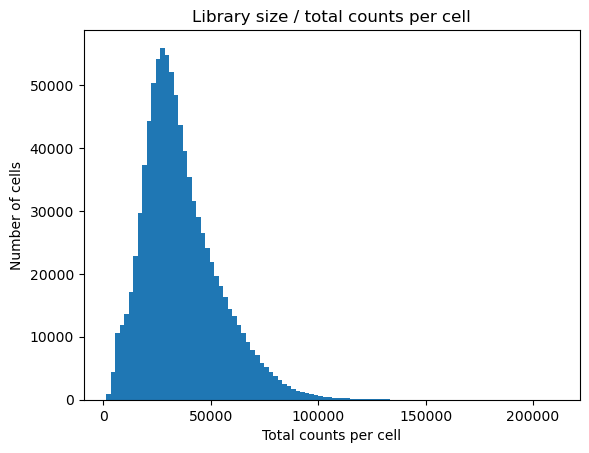

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
adata = sc.read_h5ad("../output/celldive_protein_matrix_celltypes.h5ad")

cell_sums = np.array(adata.X.sum(axis=1)).flatten()
plt.hist(cell_sums, bins=100)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Library size / total counts per cell")
plt.show()


## 2. Arcsinh transform & scale

Compress imaging dynamic range, keep raw intensities in `layers['raw']`, then z-score markers (clip ±10). Adjust `cofactor` if needed.

This is a continuous-intensity embedding path — we are **not** re-applying binary gates here.


In [2]:
cofactor = 150.0  # may need to play around with this value
adata.layers["raw"] = adata.X.copy()
adata.X = np.arcsinh(adata.X / cofactor)

sc.pp.scale(adata, max_value=10)


## 3. PCA & neighbors

Build PCA and a kNN graph in PC space. With 23 markers, `n_pcs = min(20, n_vars - 1)`.


In [3]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(20, adata.n_vars - 1))


## 4. UMAP

Slow on the full ~900k-cell object. If this succeeds, avoid re-running it unless neighbors/PCA change.

`sc.tl.umap` only **computes** coordinates (`adata.obsm['X_umap']`); it does not draw a figure. Plotting is in §6–§7.


In [4]:
sc.tl.umap(adata)


## 5. Leiden clustering

`resolution=0.5` is moderately coarse (fewer, larger clusters). Raise it for finer partitions.

Leiden finds neighborhoods from marker similarity alone — independent of the rule-based `cell_type` labels.


In [5]:
sc.tl.leiden(adata, resolution=0.5)


/tmp/ipykernel_50676/2104492833.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


### Checkpoint (recommended)

Write an embedding checkpoint so a later crash or kernel restart does **not** force re-running UMAP. Reload with `sc.read_h5ad(...)` and jump to plotting / §9.


In [6]:
from pathlib import Path

CHECKPOINT = Path("../output/celldive_protein_matrix_celltypes_umap_leiden.h5ad")
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(CHECKPOINT)
print(f"Wrote checkpoint: {CHECKPOINT.resolve()}")
print("Contains: arcsinh+scaled X, PCA, neighbors, X_umap, leiden (r=0.5).")


Wrote checkpoint: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix_celltypes_umap_leiden.h5ad
Contains: arcsinh+scaled X, PCA, neighbors, X_umap, leiden (r=0.5).


## 6. Plot UMAP — default Scanpy palette

Baseline plot with Scanpy's default categorical palette for `cell_type` and Leiden side by side.

**What to look for:**
- Left (`cell_type`): do rule-based labels form clean territories, or mix in the same regions?
- Right (`leiden`): does continuous marker space still show clear structure?
- Especially: do **Unassigned** / **Artifact_Spillover** form one island, or scatter across the manifold?


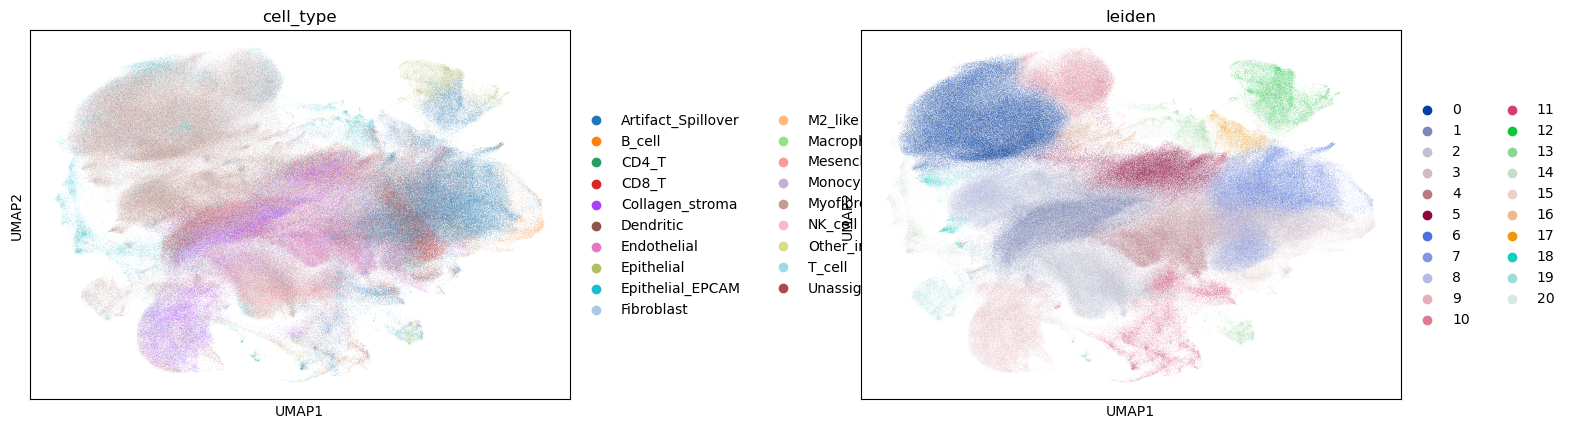

In [7]:
sc.pl.umap(adata, color=["cell_type", "leiden"], wspace=0.4)


### Why improve the palette?

With ~19 cell types on a dense cloud, Scanpy's **default categorical colors are hard to tell apart** (many similar blues, greens, and oranges). That makes the left panel misleading for discussion: you cannot reliably track Unassigned vs spillover vs named types.

We keep §6 unchanged as a baseline, then show the clearer version below. The change is a **visualization** improvement only — not a change to the embedding or clustering math.


## 7. Plot UMAP — improved palette

Same embedding and Leiden clusters as §6; only colors / highlighting change:

- Custom high-contrast palette (`adata.uns["cell_type_colors"]`)
- **Unassigned** = black, **Artifact_Spillover** = magenta
- Light transparency so overlaps remain visible
- Extra plot: only those two labels colored; everything else grey


In [ ]:
# Distinct categorical colors. Unassigned / Artifact_Spillover get high-salience colors.
CELL_TYPE_COLORS = {
    "Artifact_Spillover": "#D500F9",  # magenta
    "Unassigned": "#000000",  # black
    "Myofibroblast": "#E69F00",
    "Collagen_stroma": "#56B4E9",
    "Mesenchymal": "#009E73",
    "Epithelial_EPCAM": "#F0E442",
    "Endothelial": "#0072B2",
    "Fibroblast": "#CC79A7",
    "CD8_T": "#D55E00",
    "Epithelial": "#8B8B8B",
    "B_cell": "#1B9E77",
    "CD4_T": "#7570B3",
    "T_cell": "#E7298A",
    "Other_immune": "#66A61E",
    "Macrophage": "#A6761D",
    "Dendritic": "#A6CEE3",
    "Monocyte": "#B2DF8A",
    "M2_like": "#FB9A99",
    "NK_cell": "#CAB2D6",
}

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
adata.uns["cell_type_colors"] = [
    CELL_TYPE_COLORS.get(str(c), "#7F7F7F") for c in adata.obs["cell_type"].cat.categories
]

sc.pl.umap(
    adata,
    color="cell_type",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="cell_type (high-contrast palette)",
)

sc.pl.umap(
    adata,
    color="leiden",
    palette="tab20",
    size=8,
    alpha=0.35,
    legend_fontsize=8,
    legend_loc="right margin",
    title="leiden",
)

# Easier view of where the investigation targets sit
focus = {"Unassigned", "Artifact_Spillover"}
adata.obs["focus_label"] = (
    adata.obs["cell_type"]
    .astype(str)
    .where(adata.obs["cell_type"].astype(str).isin(focus), other="Other")
    .astype("category")
)
adata.uns["focus_label_colors"] = [
    {"Unassigned": "#000000", "Artifact_Spillover": "#D500F9", "Other": "#D0D0D0"}[str(c)]
    for c in adata.obs["focus_label"].cat.categories
]
sc.pl.umap(
    adata,
    color="focus_label",
    size=8,
    alpha=0.4,
    legend_loc="right margin",
    title="Unassigned / Artifact_Spillover vs other",
)


NameError: name 'adata' is not defined

## 8. Interpretation

Use this section to record what the UMAPs imply for Unassigned / Artifact_Spillover. Update after re-plotting if results change.

### Library size
- Peak around ~25–30k total intensity; bulk roughly ~10–75k; long bright tail.
- Not piled at zero → empty / near-zero **cells** look largely filtered already.
- Remaining per-marker zeros are expected biology (negative markers), not evidence that “zeros weren’t removed.”

### Original vs Leiden structure (from §6)
- **Left (`cell_type`):** many rule-based types mix in the main cloud; only a few groups form sharp islands (e.g. bottom-left stroma-like region; small top-right epithelial-like islands).
- **Right (`leiden`):** ~21 contiguous clusters — continuous marker space **does** have structure that binary rules do not cleanly recover.
- That mismatch is the core finding: gating labels and unsupervised neighborhoods disagree in the dense regions.

### What this means for Unassigned / Artifact_Spillover
| Pattern | Interpretation |
|---|---|
| One tight Leiden island dominated by Unassigned or spillover | Coherent leftover class (missing rule or real artifact type) |
| Spread across many Leiden clusters / mixed into named-type clouds | Residues of gate edges, incomplete rules, or mixed phenotypes — not one junk pile |
| Named types that match Leiden islands cleanly | Rule successes; leave those alone |
| Named types split across several Leiden clusters | Heterogeneity or threshold-unstable assignments within that label |

Observed pattern so far: Unassigned / spillover appear **spread through the manifold** rather than as a single remote blob → favors refining rules/thresholds **per neighborhood**, not assuming one global cutoff fix or a single leftover zero-cell artifact.

### Suggested next quantitative checks
```python
pd.crosstab(adata.obs["leiden"], adata.obs["cell_type"], normalize="index")
```
Then inspect marker means for Leiden clusters enriched in Unassigned or Artifact_Spillover (ties back to `investigate_unassigned_spillover.ipynb`).


## 9. Drill into Unassigned / spillover for salvage

Next step after the UMAPs: **drill into Unassigned clusters** and ask whether some cells can be **salvaged** into real phenotypes. Useful quantitative check: **crosstabs of Leiden at several resolutions vs `cell_type`**, plus **marker means per cluster** (especially for spillover-enriched neighborhoods).

Assumes §1–§5 already ran (neighbors graph exists). Re-running UMAP is **not** required.

Plan:
1. Leiden at multiple resolutions (coarse → fine).
2. Composition crosstabs: Leiden × `cell_type` (Unassigned / Artifact_Spillover fractions).
3. Marker mean heatmaps for clusters enriched in those labels.
4. Short salvage candidate table (clusters worth discussing for rule refinement).


### 9.1 Multi-resolution Leiden

Keep the §5 result in `obs['leiden']` (resolution 0.5). Add parallel columns at other resolutions so we can compare composition without overwriting that run.


In [9]:
# Multi-resolution Leiden on the existing neighbors graph (no UMAP recompute).
# §5 already wrote obs['leiden'] at resolution=0.5; keep it and add named columns.
LEIDEN_RESOLUTIONS = {
    "leiden_r03": 0.3,  # coarser
    "leiden": 0.5,      # already computed in §5; skip if present
    "leiden_r10": 1.0,  # finer
}

for key, res in LEIDEN_RESOLUTIONS.items():
    if key == "leiden" and "leiden" in adata.obs:
        print(f"{key}: keep existing (§5), n_clusters={adata.obs['leiden'].nunique()}")
        continue
    sc.tl.leiden(adata, resolution=res, key_added=key)
    print(f"{key}: resolution={res}, n_clusters={adata.obs[key].nunique()}")

print("\nLeiden columns:", [c for c in adata.obs.columns if c.startswith("leiden")])


leiden_r03: resolution=0.3, n_clusters=14
leiden: keep existing (§5), n_clusters=21
leiden_r10: resolution=1.0, n_clusters=34

Leiden columns: ['leiden', 'leiden_r03', 'leiden_r10']


### 9.2 Composition crosstabs (Leiden × cell_type)

For each resolution, show row-normalized composition (fraction of each Leiden cluster that is each `cell_type`). Then summarize Unassigned and Artifact_Spillover fractions to find enrichment targets.


In [10]:
from IPython.display import display

FOCUS_LABELS = ["Unassigned", "Artifact_Spillover"]
leiden_keys = [k for k in ("leiden_r03", "leiden", "leiden_r10") if k in adata.obs]

ctabs = {}
focus_summary = {}

for key in leiden_keys:
    # Cast to str so cluster IDs match across crosstab / heatmaps / highlight plots
    leiden_str = adata.obs[key].astype(str)
    ctab = pd.crosstab(leiden_str, adata.obs["cell_type"], normalize="index")
    preferred = [c for c in FOCUS_LABELS if c in ctab.columns] + [
        c for c in ctab.columns if c not in FOCUS_LABELS
    ]
    ctab = ctab.reindex(columns=preferred)
    ctabs[key] = ctab

    focus = ctab.reindex(columns=FOCUS_LABELS, fill_value=0.0).copy()
    focus["focus_total"] = focus[FOCUS_LABELS].sum(axis=1)
    focus["n_cells"] = leiden_str.value_counts().reindex(focus.index).fillna(0).astype(int)
    focus = focus.sort_values("focus_total", ascending=False)
    focus_summary[key] = focus

    print(f"\n=== {key}: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===")
    display(ctab.loc[focus.head(8).index, preferred].style.format("{:.2%}"))
    print(f"\n{key}: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)")
    display(
        focus.head(12).style.format(
            {**{c: "{:.2%}" for c in FOCUS_LABELS + ["focus_total"]}, "n_cells": "{:,}"}
        )
    )



=== leiden_r03: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


cell_type,Unassigned,Artifact_Spillover,B_cell,CD4_T,CD8_T,Collagen_stroma,Dendritic,Endothelial,Epithelial,Epithelial_EPCAM,Fibroblast,M2_like,Macrophage,Mesenchymal,Monocyte,Myofibroblast,NK_cell,Other_immune,T_cell
leiden_r03,,,,,,,,,,,,,,,,,,,
0,8.97%,52.09%,3.85%,3.51%,15.05%,3.98%,0.91%,1.83%,0.19%,2.00%,1.22%,0.16%,0.14%,1.47%,0.23%,1.44%,0.08%,0.06%,2.84%
8,0.01%,49.74%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,50.16%,0.08%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
10,14.61%,34.42%,0.57%,0.05%,0.64%,4.79%,0.21%,9.40%,0.17%,1.59%,0.20%,0.61%,0.03%,4.03%,5.65%,0.71%,0.00%,19.14%,3.18%
11,0.23%,42.53%,1.85%,1.95%,7.03%,0.00%,0.24%,0.03%,0.66%,1.82%,33.87%,0.12%,0.95%,0.02%,0.26%,6.67%,0.00%,0.01%,1.75%
2,23.23%,3.30%,0.31%,0.05%,2.21%,27.03%,0.03%,2.00%,0.76%,6.04%,3.44%,0.17%,1.56%,14.85%,0.03%,14.48%,0.13%,0.01%,0.37%
3,26.27%,0.15%,0.00%,0.02%,0.01%,16.02%,0.00%,0.83%,0.48%,6.70%,5.09%,0.01%,0.00%,11.02%,0.06%,33.22%,0.00%,0.06%,0.05%
13,9.86%,10.92%,0.93%,0.73%,2.05%,10.26%,0.07%,4.96%,0.20%,24.95%,4.63%,0.07%,0.07%,4.50%,0.07%,25.48%,0.26%,0.00%,0.00%
5,8.29%,12.29%,0.02%,0.01%,0.33%,10.91%,0.01%,40.82%,0.10%,2.04%,3.48%,0.03%,0.07%,15.46%,0.02%,6.05%,0.01%,0.01%,0.04%



leiden_r03: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r03,,,,
0,8.97%,52.09%,61.06%,"194,298"
8,0.01%,49.74%,49.76%,"22,950"
10,14.61%,34.42%,49.03%,"18,486"
11,0.23%,42.53%,42.76%,"9,177"
2,23.23%,3.30%,26.53%,"113,470"
3,26.27%,0.15%,26.42%,"113,293"
13,9.86%,10.92%,20.78%,"1,511"
5,8.29%,12.29%,20.58%,"69,382"
6,19.18%,0.07%,19.25%,"47,103"



=== leiden: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


...

cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden,,,,
6,2.17%,75.87%,78.04%,"64,457"
3,14.55%,51.64%,66.18%,"74,202"
11,8.64%,42.61%,51.24%,"34,010"
12,0.07%,49.20%,49.27%,"23,051"
17,0.03%,46.99%,47.02%,"7,748"
15,14.43%,25.74%,40.18%,"8,896"
7,10.30%,22.96%,33.25%,"49,525"
5,29.31%,3.49%,32.79%,"65,932"
1,29.32%,0.39%,29.72%,"113,605"



=== leiden_r10: row-normalized Leiden × cell_type (top 8 by Unassigned+spillover) ===


cell_type,Unassigned,Artifact_Spillover,B_cell,CD4_T,CD8_T,Collagen_stroma,Dendritic,Endothelial,Epithelial,Epithelial_EPCAM,Fibroblast,M2_like,Macrophage,Mesenchymal,Monocyte,Myofibroblast,NK_cell,Other_immune,T_cell
leiden_r10,,,,,,,,,,,,,,,,,,,
29,0.13%,86.80%,7.35%,0.52%,2.11%,0.52%,0.00%,0.00%,0.23%,0.00%,2.24%,0.00%,0.00%,0.07%,0.00%,0.00%,0.00%,0.00%,0.03%
2,1.05%,81.58%,1.93%,2.45%,10.72%,0.36%,0.12%,0.40%,0.03%,0.05%,0.07%,0.02%,0.18%,0.40%,0.00%,0.11%,0.03%,0.00%,0.50%
32,30.31%,43.72%,0.74%,2.22%,3.06%,0.21%,0.11%,4.86%,0.00%,5.49%,0.00%,0.00%,0.00%,1.16%,0.00%,5.07%,0.00%,0.00%,3.06%
19,0.70%,73.28%,25.46%,0.00%,0.02%,0.16%,0.00%,0.17%,0.00%,0.06%,0.01%,0.00%,0.00%,0.14%,0.00%,0.00%,0.00%,0.00%,0.00%
5,19.54%,42.35%,3.49%,2.01%,4.75%,2.82%,0.12%,4.81%,0.66%,5.46%,3.94%,0.07%,0.16%,2.88%,0.32%,3.15%,0.02%,0.07%,3.37%
16,1.30%,49.72%,1.19%,0.01%,3.70%,0.30%,1.05%,6.66%,0.03%,2.61%,3.37%,0.02%,0.73%,18.90%,1.16%,9.03%,0.01%,0.19%,0.03%
14,0.07%,49.50%,0.00%,0.00%,0.01%,0.01%,0.00%,0.00%,50.33%,0.08%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
24,0.01%,49.38%,2.17%,2.73%,8.57%,0.00%,0.25%,0.03%,0.66%,2.05%,30.29%,0.12%,1.02%,0.02%,0.28%,0.00%,0.00%,0.01%,2.38%



leiden_r10: Unassigned / Artifact_Spillover enrichment (sorted by focus_total)


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r10,,,,
29,0.13%,86.80%,86.93%,"3,075"
2,1.05%,81.58%,82.63%,"64,562"
32,30.31%,43.72%,74.02%,947
19,0.70%,73.28%,73.98%,"13,760"
5,19.54%,42.35%,61.89%,"48,683"
16,1.30%,49.72%,51.02%,"17,645"
14,0.07%,49.50%,49.57%,"23,205"
24,0.01%,49.38%,49.39%,"8,817"
9,47.15%,0.18%,47.33%,"44,535"


### 9.3 Marker means for Unassigned / spillover-enriched clusters

For each resolution, take clusters with high Unassigned or Artifact_Spillover fraction and plot mean arcsinh+scaled marker intensity (same `adata.X` as the embedding). Nuclear channels skipped. Companion to the composition crosstabs—especially useful for spillover (multi-lineage / bleed signatures).



=== leiden_r03: mean marker intensity for Unassigned/spillover-enriched clusters (n=10; gate focus_total≥25% or top 10) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r03,,,,
0,8.97%,52.09%,61.06%,"194,298"
8,0.01%,49.74%,49.76%,"22,950"
10,14.61%,34.42%,49.03%,"18,486"
11,0.23%,42.53%,42.76%,"9,177"
2,23.23%,3.30%,26.53%,"113,470"
3,26.27%,0.15%,26.42%,"113,293"
13,9.86%,10.92%,20.78%,"1,511"
5,8.29%,12.29%,20.58%,"69,382"
6,19.18%,0.07%,19.25%,"47,103"


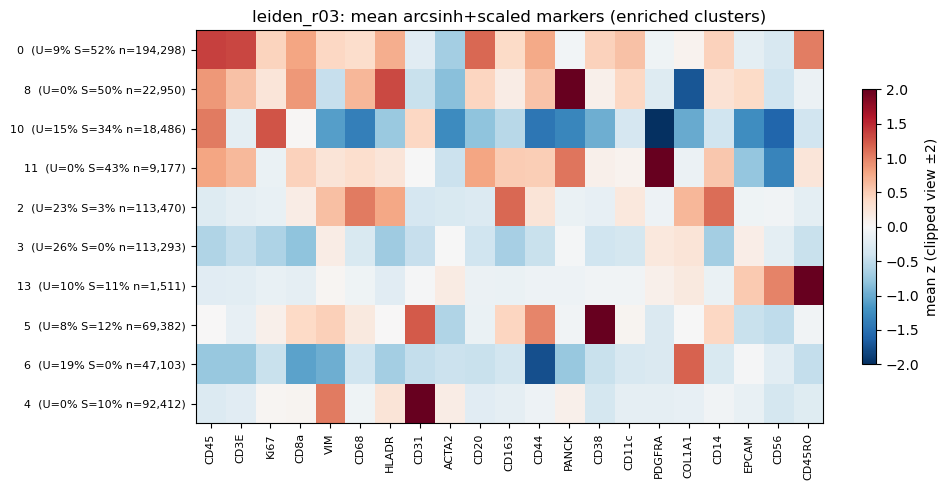


=== leiden: mean marker intensity for Unassigned/spillover-enriched clusters (n=10; gate focus_total≥25% or top 10) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden,,,,
6,2.17%,75.87%,78.04%,"64,457"
3,14.55%,51.64%,66.18%,"74,202"
11,8.64%,42.61%,51.24%,"34,010"
12,0.07%,49.20%,49.27%,"23,051"
17,0.03%,46.99%,47.02%,"7,748"
15,14.43%,25.74%,40.18%,"8,896"
7,10.30%,22.96%,33.25%,"49,525"
5,29.31%,3.49%,32.79%,"65,932"
1,29.32%,0.39%,29.72%,"113,605"


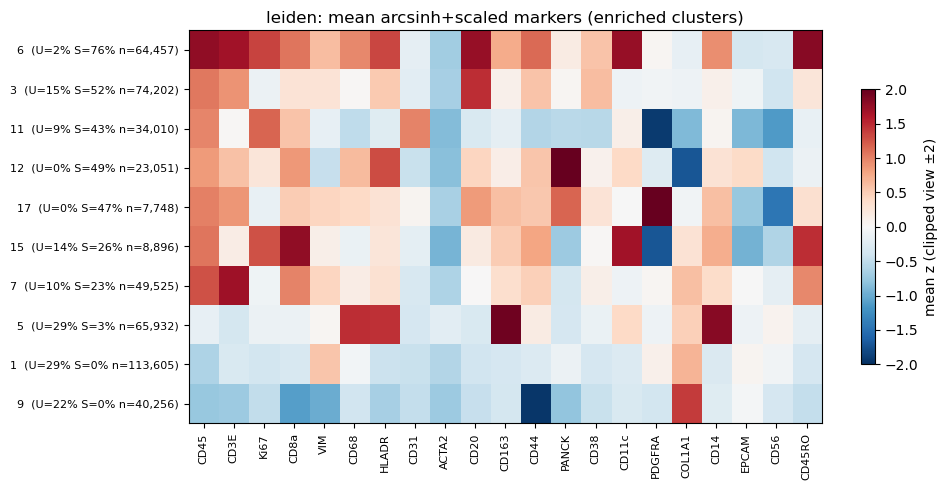


=== leiden_r10: mean marker intensity for Unassigned/spillover-enriched clusters (n=16; gate focus_total≥25% or top 10) ===


cell_type,Unassigned,Artifact_Spillover,focus_total,n_cells
leiden_r10,,,,
29,0.13%,86.80%,86.93%,"3,075"
2,1.05%,81.58%,82.63%,"64,562"
32,30.31%,43.72%,74.02%,947
19,0.70%,73.28%,73.98%,"13,760"
5,19.54%,42.35%,61.89%,"48,683"
16,1.30%,49.72%,51.02%,"17,645"
14,0.07%,49.50%,49.57%,"23,205"
24,0.01%,49.38%,49.39%,"8,817"
9,47.15%,0.18%,47.33%,"44,535"


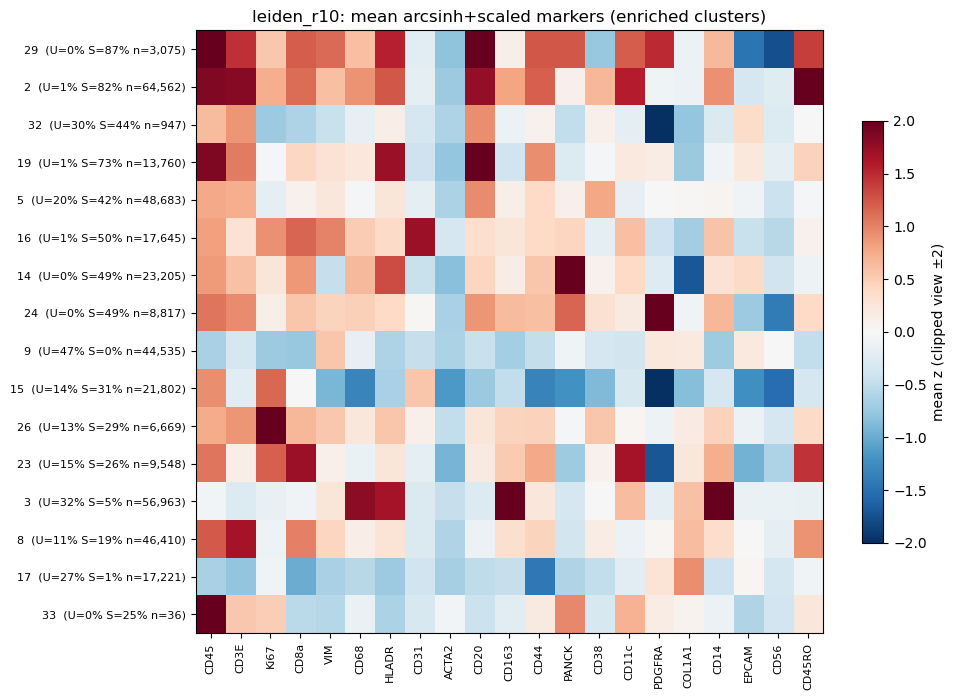

In [11]:
SKIP_MARKERS = {"DAPI", "DAPI2"}
markers = [m for m in adata.var_names if m not in SKIP_MARKERS]
marker_idx = [list(adata.var_names).index(m) for m in markers]

# Enrichment gate: either focus label ≥ this fraction, or among top-N by focus_total
MIN_FOCUS_FRAC = 0.25
TOP_N_CLUSTERS = 10

cluster_marker_means = {}

for key in leiden_keys:
    focus = focus_summary[key]
    enriched = focus.index[
        (focus["focus_total"] >= MIN_FOCUS_FRAC)
        | (focus.index.isin(focus.head(TOP_N_CLUSTERS).index))
    ].tolist()
    # keep sort by focus_total
    enriched = [c for c in focus.index if c in set(enriched)]

    rows = []
    for cl in enriched:
        mask = (adata.obs[key].astype(str) == str(cl)).to_numpy()
        if mask.sum() == 0:
            continue
        means = np.asarray(adata.X[mask][:, marker_idx].mean(axis=0)).ravel()
        rows.append(pd.Series(means, index=markers, name=str(cl)))

    mean_df = pd.DataFrame(rows)
    mean_df.index.name = key
    cluster_marker_means[key] = mean_df

    print(
        f"\n=== {key}: mean marker intensity for Unassigned/spillover-enriched clusters "
        f"(n={len(mean_df)}; gate focus_total≥{MIN_FOCUS_FRAC:.0%} or top {TOP_N_CLUSTERS}) ==="
    )
    if mean_df.empty:
        print("No enriched clusters.")
        continue

    # Annotate with Unassigned / spillover fractions for context
    annot = focus.loc[mean_df.index, FOCUS_LABELS + ["focus_total", "n_cells"]]
    display(annot.style.format({**{c: "{:.2%}" for c in FOCUS_LABELS + ["focus_total"]}, "n_cells": "{:,}"}))

    fig, ax = plt.subplots(
        figsize=(max(10, 0.45 * len(markers)), max(3.5, 0.35 * len(mean_df) + 1.5))
    )
    im = ax.imshow(mean_df.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(range(len(markers)))
    ax.set_xticklabels(markers, rotation=90, fontsize=8)
    ax.set_yticks(range(len(mean_df)))
    ax.set_yticklabels(
        [
            f"{cl}  (U={annot.loc[cl, 'Unassigned']:.0%} S={annot.loc[cl, 'Artifact_Spillover']:.0%} n={annot.loc[cl, 'n_cells']:,})"
            for cl in mean_df.index
        ],
        fontsize=8,
    )
    ax.set_title(f"{key}: mean arcsinh+scaled markers (enriched clusters)")
    fig.colorbar(im, ax=ax, shrink=0.7, label="mean z (clipped view ±2)")
    plt.tight_layout()
    plt.show()


### 9.4 Salvage candidates

Clusters with **high Unassigned** and a **lineage-like marker profile** are salvage candidates (missing/edge rule). Clusters with **high Artifact_Spillover** and **mixed / multi-lineage markers** are less salvageable as a single type—more likely bleed or doublets; still useful for threshold/rule review.

Below: top markers (by mean intensity) for the most enriched clusters at each resolution, plus a compact candidate table.


In [12]:
TOP_MARKERS = 8
N_SHOW = 8  # clusters per resolution

candidate_rows = []

for key in leiden_keys:
    focus = focus_summary[key]
    mean_df = cluster_marker_means.get(key)
    if mean_df is None or mean_df.empty:
        continue

    print(f"\n=== {key}: top markers for Unassigned/spillover-enriched clusters ===")
    for cl in mean_df.index[:N_SHOW]:
        top = mean_df.loc[cl].sort_values(ascending=False).head(TOP_MARKERS)
        u = focus.loc[cl, "Unassigned"]
        s = focus.loc[cl, "Artifact_Spillover"]
        n = int(focus.loc[cl, "n_cells"])
        top_str = ", ".join(f"{m}={v:.2f}" for m, v in top.items())
        print(f"  cluster {cl} (n={n:,}, Unassigned={u:.1%}, Spillover={s:.1%}): {top_str}")

        # Heuristic flags for discussion (not auto-relabeling)
        dominant = "Unassigned" if u >= s else "Artifact_Spillover"
        if u >= 0.35 and s < 0.20:
            note = "Unassigned-heavy → possible salvage / missing rule"
        elif s >= 0.35:
            note = "Spillover-heavy → review bleed / multi-marker gates"
        elif u + s >= 0.40:
            note = "Mixed leftover pool → inspect top markers vs neighbors"
        else:
            note = "Moderate enrichment"
        candidate_rows.append(
            {
                "leiden_key": key,
                "cluster": str(cl),
                "n_cells": n,
                "frac_Unassigned": u,
                "frac_Artifact_Spillover": s,
                "focus_total": u + s,
                "dominant_focus": dominant,
                "top_markers": ", ".join(top.index.tolist()),
                "note": note,
            }
        )

candidates = pd.DataFrame(candidate_rows)
if not candidates.empty:
    candidates = candidates.sort_values(
        ["leiden_key", "focus_total"], ascending=[True, False]
    )
    print("\n=== Salvage / review candidate table ===")
    display(
        candidates.style.format(
            {
                "frac_Unassigned": "{:.1%}",
                "frac_Artifact_Spillover": "{:.1%}",
                "focus_total": "{:.1%}",
                "n_cells": "{:,}",
            }
        )
    )
else:
    print("No candidate clusters.")



=== leiden_r03: top markers for Unassigned/spillover-enriched clusters ===
  cluster 0 (n=194,298, Unassigned=9.0%, Spillover=52.1%): CD45=1.37, CD3E=1.34, CD20=1.15, CD45RO=1.03, CD8a=0.80, CD44=0.75, HLADR=0.73, CD11c=0.59
  cluster 8 (n=22,950, Unassigned=0.0%, Spillover=49.7%): PANCK=4.93, HLADR=1.32, CD8a=0.87, CD45=0.86, CD68=0.66, CD3E=0.59, CD44=0.56, CD20=0.44
  cluster 10 (n=18,486, Unassigned=14.6%, Spillover=34.4%): Ki67=1.26, CD45=1.05, CD31=0.42, CD8a=0.03, CD3E=-0.19, CD11c=-0.34, CD45RO=-0.39, CD14=-0.40
  cluster 11 (n=9,177, Unassigned=0.2%, Spillover=42.5%): PDGFRA=3.11, PANCK=1.06, CD45=0.79, CD20=0.78, CD3E=0.66, CD14=0.53, CD163=0.51, CD44=0.49
  cluster 2 (n=113,470, Unassigned=23.2%, Spillover=3.3%): CD163=1.15, CD14=1.12, CD68=1.04, HLADR=0.78, COL1A1=0.66, VIM=0.60, CD44=0.26, CD11c=0.21
  cluster 3 (n=113,293, Unassigned=26.3%, Spillover=0.2%): COL1A1=0.26, PDGFRA=0.22, VIM=0.15, EPCAM=0.14, ACTA2=-0.00, PANCK=-0.04, CD56=-0.19, CD68=-0.30
  cluster 13 (n=1,

,leiden_key,cluster,n_cells,frac_Unassigned,frac_Artifact_Spillover,focus_total,dominant_focus,top_markers,note
8,leiden,6,"64,457",2.2%,75.9%,78.0%,Artifact_Spillover,"CD45RO, CD45, CD11c, CD20, CD3E, Ki67, HLADR, CD44",Spillover-heavy → review bleed / multi-marker gates
9,leiden,3,"74,202",14.5%,51.6%,66.2%,Artifact_Spillover,"CD20, CD45, CD3E, CD38, CD44, HLADR, VIM, CD8a",Spillover-heavy → review bleed / multi-marker gates
10,leiden,11,"34,010",8.6%,42.6%,51.2%,Artifact_Spillover,"Ki67, CD31, CD45, CD8a, CD11c, CD14, CD3E, CD45RO",Spillover-heavy → review bleed / multi-marker gates
11,leiden,12,"23,051",0.1%,49.2%,49.3%,Artifact_Spillover,"PANCK, HLADR, CD8a, CD45, CD68, CD3E, CD44, CD20",Spillover-heavy → review bleed / multi-marker gates
12,leiden,17,"7,748",0.0%,47.0%,47.0%,Artifact_Spillover,"PDGFRA, PANCK, CD45, CD3E, CD20, CD14, CD163, CD44",Spillover-heavy → review bleed / multi-marker gates
13,leiden,15,"8,896",14.4%,25.7%,40.2%,Artifact_Spillover,"CD8a, CD11c, CD45RO, Ki67, CD45, CD44, CD14, CD163",Mixed leftover pool → inspect top markers vs neighbors
14,leiden,7,"49,525",10.3%,23.0%,33.3%,Artifact_Spillover,"CD3E, CD45, CD8a, CD45RO, COL1A1, CD44, VIM, CD14",Moderate enrichment
15,leiden,5,"65,932",29.3%,3.5%,32.8%,Unassigned,"CD163, CD14, CD68, HLADR, COL1A1, CD11c, CD44, CD56",Moderate enrichment
0,leiden_r03,0,"194,298",9.0%,52.1%,61.1%,Artifact_Spillover,"CD45, CD3E, CD20, CD45RO, CD8a, CD44, HLADR, CD11c",Spillover-heavy → review bleed / multi-marker gates
1,leiden_r03,8,"22,950",0.0%,49.7%,49.8%,Artifact_Spillover,"PANCK, HLADR, CD8a, CD45, CD68, CD3E, CD44, CD20",Spillover-heavy → review bleed / multi-marker gates


### 9.5 UMAP: highlight Unassigned/spillover-enriched Leiden clusters

Map the top enriched clusters (from the §5 `leiden` resolution) onto UMAP for visual inspection of those neighborhoods.


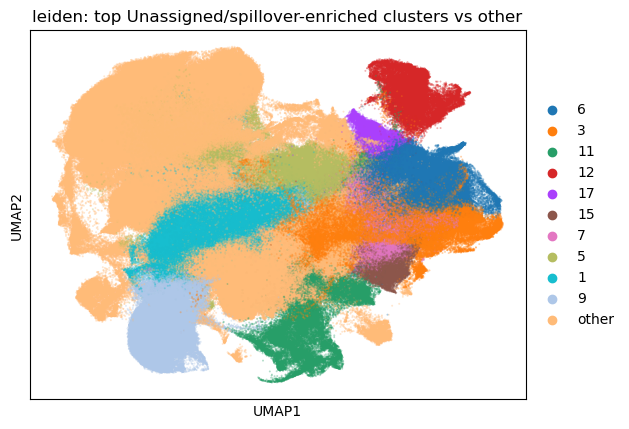

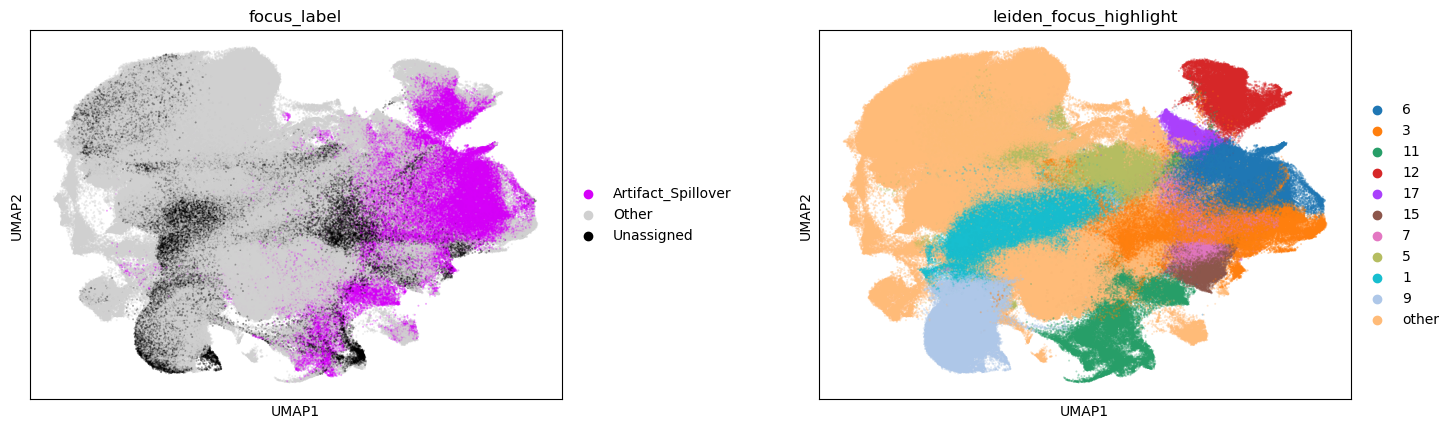

In [13]:
# Highlight top enriched clusters from the default leiden (§5 / resolution 0.5)
key = "leiden" if "leiden" in focus_summary else leiden_keys[0]
top_enriched = focus_summary[key].head(TOP_N_CLUSTERS).index.astype(str).tolist()

adata.obs["leiden_focus_highlight"] = (
    adata.obs[key]
    .astype(str)
    .where(adata.obs[key].astype(str).isin(top_enriched), other="other")
    .astype("category")
)

# Put "other" last in the legend
cats = [c for c in top_enriched if c in adata.obs["leiden_focus_highlight"].cat.categories] + (
    ["other"] if "other" in adata.obs["leiden_focus_highlight"].cat.categories else []
)
adata.obs["leiden_focus_highlight"] = adata.obs["leiden_focus_highlight"].cat.reorder_categories(
    cats, ordered=True
)

sc.pl.umap(
    adata,
    color="leiden_focus_highlight",
    size=8,
    alpha=0.35,
    legend_loc="right margin",
    title=f"{key}: top Unassigned/spillover-enriched clusters vs other",
)

# Side-by-side: cell_type focus vs enriched Leiden
sc.pl.umap(
    adata,
    color=["focus_label", "leiden_focus_highlight"],
    size=8,
    alpha=0.35,
    wspace=0.35,
)


## 10. Binary gates & phenotyping matrix (cutoff / salvage diagnostics)

§9 uses **continuous** arcsinh+scaled markers for Leiden and heatmaps. Rule labels (`cell_type`, spillover) come from **`layers['binary']`** and the gates in `analyze_cell_types_from_markers.ipynb`.

This section connects enriched Leiden pockets back to **actionable gate logic**:

1. **Spillover pair breakdown** — which impossible pair(s) fired (CD3E+CD20+, CD45+CD31+, …)?
2. **Binary positivity** — per cluster, compare spillover / Unassigned / assigned cells on each marker.
3. **Phenotyping matrix fit** — which lineage column in `input/Cell Phenotyping Matrix.csv` best matches each cluster's binary profile?

Requires §9 (`focus_summary` from crosstabs). Attaches `layers['binary']` from the source `.h5ad` if the checkpoint lacks it.


### 10.1 Spillover pair breakdown per enriched cluster

For each Leiden cluster enriched in Artifact_Spillover: among **spillover-labeled cells in that cluster**, count which **impossible pair** triggered the flag. This tells you which marker(s) to revisit (e.g. relax CD20 cutoff vs CD3E cutoff for T+B gate).


In [ ]:
def spillover_pair_table(indices: np.ndarray) -> pd.DataFrame:
    """Fraction of cells (in indices) positive for each spillover pair."""
    rows = []
    n = len(indices)
    for m1, m2, reason in SPILLOVER_GATES:
        if m1 not in marker_to_col or m2 not in marker_to_col:
            continue
        c1, c2 = marker_to_col[m1], marker_to_col[m2]
        hit = (X_bin[indices, c1] == 1) & (X_bin[indices, c2] == 1)
        rows.append(
            {
                "gate": f"{m1}+ & {m2}+",
                "reason": reason,
                "n_cells": int(hit.sum()),
                "frac_of_subset": hit.sum() / n if n else 0.0,
            }
        )
    return pd.DataFrame(rows).sort_values("frac_of_subset", ascending=False)


pair_rows = []
leiden_str = adata.obs[DRILL_KEY].astype(str).to_numpy()

for cl in top_clusters:
    in_cl = leiden_str == cl
    sp_in_cl = np.where(in_cl & mask_spill)[0]
    n_sp = len(sp_in_cl)
    fu = (ct[in_cl] == "Unassigned").mean()
    fs = (ct[in_cl] == "Artifact_Spillover").mean()
    print(f"\n=== {DRILL_KEY} cluster {cl} (n={in_cl.sum():,}, Unassigned={fu:.1%}, Spillover={fs:.1%}) ===")
    if n_sp == 0:
        print("  No spillover-labeled cells in this cluster.")
        continue
    tbl = spillover_pair_table(sp_in_cl)
    display(tbl.style.format({"frac_of_subset": "{:.1%}"}))
    top_gate = tbl.iloc[0]["gate"] if len(tbl) else ""
    pair_rows.append(
        {
            "cluster": cl,
            "n_spillover_in_cluster": n_sp,
            "top_gate": top_gate,
            "top_gate_frac": tbl.iloc[0]["frac_of_subset"] if len(tbl) else np.nan,
        }
    )

pair_summary = pd.DataFrame(pair_rows)
if not pair_summary.empty:
    print("\n=== Spillover gate summary (top gate per enriched cluster) ===")
    display(pair_summary.style.format({"top_gate_frac": "{:.1%}"}))


### 10.2 Binary positivity per cluster (spillover vs Unassigned vs assigned)

Fraction **binary-positive** per marker, split by label within each enriched cluster. Compare to **assigned clean** cells globally (reference). Large deltas hint at cutoff tweaks or missing rules.

- **Spillover rows:** which channel is weakly positive and could be thresholded down?
- **Unassigned rows:** which lineage markers are high but didn't complete a rule (e.g. CD14+ without CD45+)?


### 10.3 Phenotyping matrix lineage fit

Score each enriched cluster's **mean binary profile** against lineage columns in `input/Cell Phenotyping Matrix.csv`:

- **`+`** expects ≥50% binary-positive in cluster  
- **`-`** expects ≤50% binary-positive  
- **`+/-`** is neutral (not scored)

Best-matching lineage suggests a **salvage label** or which matrix row to align rules with. Low scores across all columns → genuinely ambiguous / needs new rule or cutoff work.


In [ ]:
def score_lineage(profile: pd.Series, expect: pd.Series) -> tuple[float, int]:
    """Return (score, n_scored). +1 match, -1 mismatch per scored marker."""
    score, n = 0.0, 0
    for marker, req in expect.items():
        if marker not in profile.index:
            continue
        req = str(req).strip()
        if req in ("+", "-"):
            n += 1
            pos = profile[marker] >= 0.5
            if (req == "+" and pos) or (req == "-" and not pos):
                score += 1
            else:
                score -= 1
    return score, n


def best_lineages(profile: pd.Series, top_k: int = 3) -> pd.DataFrame:
    rows = []
    for col in lineage_cols:
        s, n = score_lineage(profile, pm[col])
        if n == 0:
            continue
        rows.append(
            {
                "lineage": col,
                "score": s,
                "n_scored": n,
                "pct_match": (s + n) / (2 * n),  # maps [-1,1] to [0,1]
            }
        )
    return pd.DataFrame(rows).sort_values(["score", "pct_match"], ascending=False).head(top_k)


# Pipeline rules (for cross-reference with matrix)
PIPELINE_RULES = [
    ("CD8_T", ["CD45", "CD3E", "CD8a"], []),
    ("CD4_T", ["CD45", "CD3E", "CD45RO"], ["CD8a"]),
    ("T_cell", ["CD45", "CD3E"], []),
    ("B_cell", ["CD45", "CD20"], []),
    ("NK_cell", ["CD45", "CD56"], ["CD3E"]),
    ("Macrophage", ["CD45", "CD68"], []),
    ("M2_like", ["CD45", "CD163"], []),
    ("Monocyte", ["CD45", "CD14"], []),
    ("Other_immune", ["CD45"], []),
    ("Epithelial", ["PANCK"], []),
    ("Epithelial_EPCAM", ["EPCAM"], []),
    ("Fibroblast", ["PDGFRA"], []),
    ("Myofibroblast", ["ACTA2"], []),
    ("Collagen_stroma", ["COL1A1"], []),
    ("Mesenchymal", ["VIM"], []),
    ("Endothelial", ["CD31"], []),
]


def matching_pipeline_rules(profile: pd.Series) -> list[str]:
    hits = []
    for name, pos, neg in PIPELINE_RULES:
        pos_ok = all(profile.get(m, 0) >= 0.5 for m in pos if m in profile.index)
        neg_ok = all(profile.get(m, 1) <= 0.5 for m in neg if m in profile.index)
        if pos_ok and neg_ok:
            hits.append(name)
    return hits


fit_rows = []
for cl in top_clusters:
    in_cl = leiden_str == cl
    idx_un = np.where(in_cl & mask_un)[0]
    idx_sp = np.where(in_cl & mask_spill)[0]
    idx_all = np.where(in_cl)[0]

    fu = (ct[in_cl] == "Unassigned").mean()
    fs = (ct[in_cl] == "Artifact_Spillover").mean()

    print(f"\n=== {DRILL_KEY} cluster {cl}: lineage & rule fit ===")
    for label, idx in [
        ("all cells in cluster", idx_all),
        ("Unassigned subset", idx_un),
        ("Spillover subset", idx_sp),
    ]:
        if len(idx) < 30:
            continue
        prof = binary_profile(idx)
        print(f"\n  [{label}] n={len(idx):,}")
        display(best_lineages(prof).style.format({"pct_match": "{:.0%}"}))
        rules = matching_pipeline_rules(prof)
        if rules:
            print(f"  Pipeline rules fully satisfied (binary): {', '.join(rules)}")
        else:
            print("  Pipeline rules fully satisfied (binary): none")
        fit_rows.append(
            {
                "cluster": cl,
                "subset": label,
                "n": len(idx),
                "best_lineage": best_lineages(prof).iloc[0]["lineage"] if len(best_lineages(prof)) else "",
                "best_lineage_pct": best_lineages(prof).iloc[0]["pct_match"] if len(best_lineages(prof)) else np.nan,
                "pipeline_rules_match": ", ".join(rules) if rules else "",
                "frac_Unassigned": fu,
                "frac_Spillover": fs,
            }
        )

fit_summary = pd.DataFrame(fit_rows)
if not fit_summary.empty:
    print("\n=== Lineage / rule fit summary (enriched clusters) ===")
    display(
        fit_summary.style.format(
            {
                "best_lineage_pct": "{:.0%}",
                "frac_Unassigned": "{:.1%}",
                "frac_Spillover": "{:.1%}",
            }
        )
    )
